### Data Exploration & cleaning

In [76]:
import numpy as np
import pandas as pd

# Load
df1 = pd.read_csv("data/raw/USHY_INDEX_20260301_part_1.csv")
df2 = pd.read_csv("data/raw/USHY_INDEX_20260301_part_2.csv")

# Combine
df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)
df.head()

(394342, 18)


,Date,Cusip,ISIN,Class1,Class2,Class3,Ticker,Eff_Rating_Group,Index_Rating_Number,Maturity_Date,Years_To_Maturity,DTS,OAS,OAD,OASD,Yield_To_Worst,Total_Return_MTD,Excess_Return_MTD
0,1/1/2010,004403AA,US004403AA94,Corporate,Financial_Institutions,Other_Financial,AACE,CCC,18,1/1/1900,4.67,50.16,1456.5,3.55,3.52,17.296,7.75,6.41
1,1/1/2010,00081TAB,US00081TAB44,Corporate,Industrial,Consumer_Non_Cyclical,ABD,CCC,19,1/1/1900,5.54,25.66,642.1,4.25,4.19,9.084,1.44,-0.14
2,1/1/2010,00081TAD,US00081TAD00,Corporate,Industrial,Consumer_Non_Cyclical,ABD,B,16,1/1/1900,5.12,18.98,574.1,3.56,3.50,8.115,0.34,-1.01
3,1/1/2010,043436AD,US043436AD66,Corporate,Industrial,Consumer_Cyclical,ABG,CCC,18,1/1/1900,4.12,14.39,568.3,2.74,2.69,7.857,2.66,1.49
4,1/1/2010,023139AE,US023139AE83,Corporate,Financial_Institutions,Insurance,ABK,CCC,21,1/1/1900,25.84,82.71,1710.4,4.99,4.86,21.410,3.97,2.52


In [77]:
df["Date"] = pd.to_datetime(df["Date"])
df.reset_index(drop=True, inplace=True)
df.head()

,Date,Cusip,ISIN,Class1,Class2,Class3,Ticker,Eff_Rating_Group,Index_Rating_Number,Maturity_Date,Years_To_Maturity,DTS,OAS,OAD,OASD,Yield_To_Worst,Total_Return_MTD,Excess_Return_MTD
0,2010-01-01,004403AA,US004403AA94,Corporate,Financial_Institutions,Other_Financial,AACE,CCC,18,1/1/1900,4.67,50.16,1456.5,3.55,3.52,17.296,7.75,6.41
1,2010-01-01,00081TAB,US00081TAB44,Corporate,Industrial,Consumer_Non_Cyclical,ABD,CCC,19,1/1/1900,5.54,25.66,642.1,4.25,4.19,9.084,1.44,-0.14
2,2010-01-01,00081TAD,US00081TAD00,Corporate,Industrial,Consumer_Non_Cyclical,ABD,B,16,1/1/1900,5.12,18.98,574.1,3.56,3.50,8.115,0.34,-1.01
3,2010-01-01,043436AD,US043436AD66,Corporate,Industrial,Consumer_Cyclical,ABG,CCC,18,1/1/1900,4.12,14.39,568.3,2.74,2.69,7.857,2.66,1.49
4,2010-01-01,023139AE,US023139AE83,Corporate,Financial_Institutions,Insurance,ABK,CCC,21,1/1/1900,25.84,82.71,1710.4,4.99,4.86,21.410,3.97,2.52


In [62]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

DTS                  1825
OASD                 1825
Maturity_Date         254
Ticker                  3
Total_Return_MTD        1
Yield_To_Worst          1
OAD                     1
OAS                     1
Excess_Return_MTD       1
dtype: int64

In [63]:
# gaps in the monthly time series
df["Date"].drop_duplicates().sort_values().diff().value_counts().head()

Date
31 days    113
30 days     64
28 days     13
29 days      4
Name: count, dtype: int64

2010-01-01 00:00:00 2026-03-01 00:00:00
195
10223
4004


<Axes: title={'center': 'Number of Bonds by Month'}, xlabel='Date'>

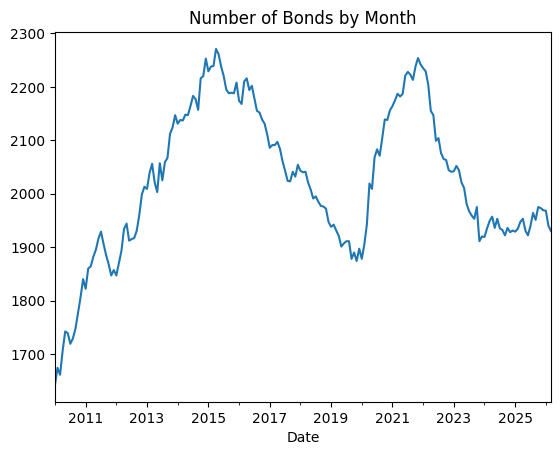

In [64]:
df["Maturity_Date"] = pd.to_datetime(df["Maturity_Date"], errors="coerce")
df.loc[df["Maturity_Date"] == "1900-01-01", "Maturity_Date"] = pd.NaT

df = df.sort_values(["Date", "ISIN"])

print(df["Date"].min(), df["Date"].max())
print(df["Date"].nunique())
print(df["ISIN"].nunique())
print(df["Ticker"].nunique())

df.groupby("Date").size().plot(title="Number of Bonds by Month")

In [65]:
summary = df.groupby("Date").agg(
    n_bonds=("ISIN", "nunique"),
    n_issuers=("Ticker", "nunique"),
    median_oas=("OAS", "median"),
    median_dts=("DTS", "median"),
    median_oad=("OAD", "median"),
    median_ytw=("Yield_To_Worst", "median"),
    avg_total_return=("Total_Return_MTD", "mean"),
    avg_excess_return=("Excess_Return_MTD", "mean"),
)

summary.head()

,n_bonds,n_issuers,median_oas,median_dts,median_oad,median_ytw,avg_total_return,avg_excess_return
Date,,,,,,,,
2010-01-01,1642,751,547.05,21.350,3.93,8.1360,2.069677,0.673252
2010-02-01,1674,753,571.95,22.640,3.96,8.3745,0.124701,-0.273883
2010-03-01,1661,753,507.50,20.070,3.90,7.9350,3.048489,3.739681
2010-04-01,1706,771,487.40,19.045,3.85,7.6470,2.638089,1.809912
2010-05-01,1742,792,602.75,24.445,3.99,8.5660,-3.115643,-4.421125


<Axes: title={'center': 'Sector Composition Over Time'}, xlabel='Date'>

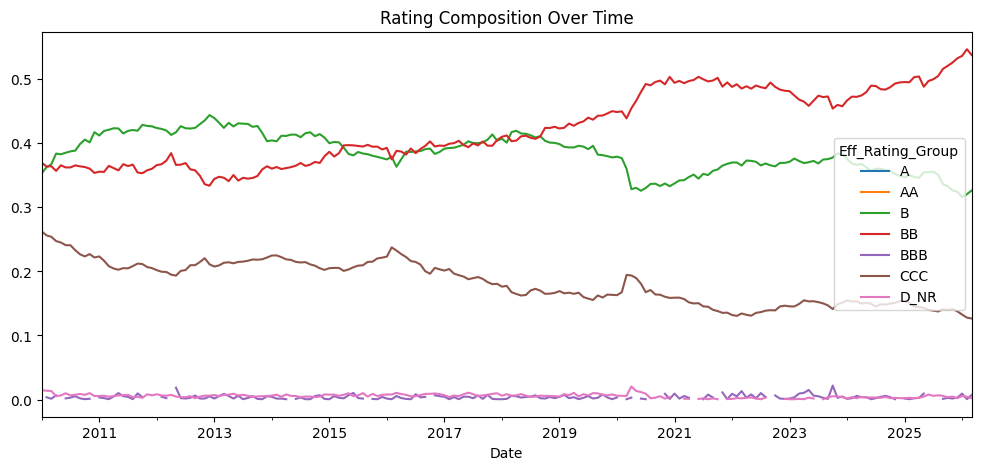

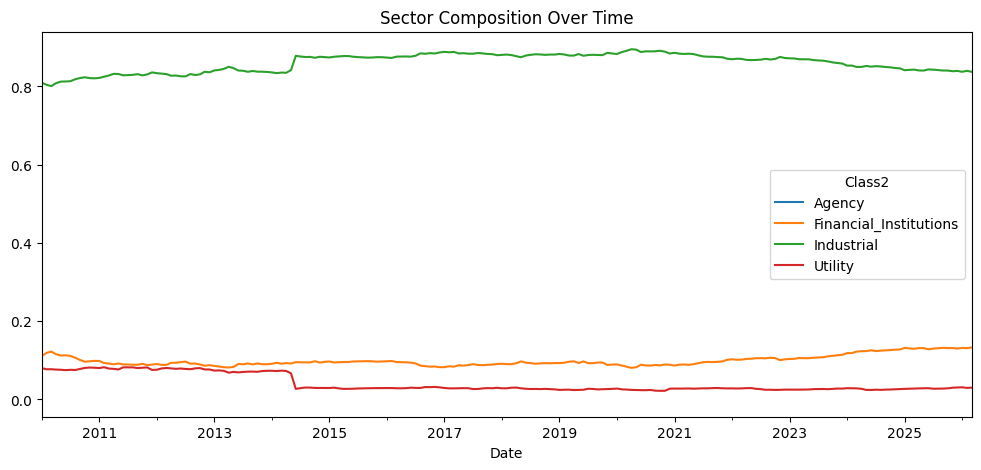

In [66]:
rating_comp = (
    df.pivot_table(index="Date", columns="Eff_Rating_Group", values="ISIN", aggfunc="count")
    .div(df.groupby("Date")["ISIN"].count(), axis=0)
)

sector_comp = (
    df.pivot_table(index="Date", columns="Class2", values="ISIN", aggfunc="count")
    .div(df.groupby("Date")["ISIN"].count(), axis=0)
)

rating_comp.plot(title="Rating Composition Over Time", figsize=(12, 5))
sector_comp.plot(title="Sector Composition Over Time", figsize=(12, 5))

first signal attempt

In [84]:
# Create a simple test signal: mean reversion on OAS
# Signal: Long when OAS is elevated (above 75th percentile), short when compressed (below 25th percentile)

portfolio_input = df.copy()

# Calculate rolling percentiles of OAS (252 trading days = 1 year)
portfolio_input['OAS_pct_75'] = portfolio_input.groupby('ISIN')['OAS'].transform(lambda x: x.rolling(window=252, min_periods=1).quantile(0.75))
portfolio_input['OAS_pct_25'] = portfolio_input.groupby('ISIN')['OAS'].transform(lambda x: x.rolling(window=252, min_periods=1).quantile(0.25))

# Generate signal: 1 = long (mean reversion play, OAS elevated), -1 = short (OAS compressed), 0 = neutral
portfolio_input['signal'] = 0
portfolio_input.loc[portfolio_input['OAS'] >= portfolio_input['OAS_pct_75'], 'signal'] = 1
portfolio_input.loc[portfolio_input['OAS'] <= portfolio_input['OAS_pct_25'], 'signal'] = -1

# Create a portfolio dataframe with signal info by date
signal_df = (
    portfolio_input.groupby('Date').agg(
        n_long=('signal', lambda x: (x == 1).sum()),
        n_short=('signal', lambda x: (x == -1).sum()),
        n_neutral=('signal', lambda x: (x == 0).sum()),
        avg_oas_long=('OAS', lambda x: x[portfolio_input.loc[x.index, 'signal'] == 1].mean()),
        avg_oas_short=('OAS', lambda x: x[portfolio_input.loc[x.index, 'signal'] == -1].mean()),
    )
)

signal_df.head(10)

,n_long,n_short,n_neutral,avg_oas_long,avg_oas_short
Date,,,,,
2010-01-01,0,1642,0,NaN,696.555603
2010-02-01,1130,544,0,696.721504,717.030331
2010-03-01,73,1348,240,1171.167123,565.960979
2010-04-01,46,1119,541,634.795652,558.793923
2010-05-01,1276,215,251,705.522571,661.703721
2010-06-01,1329,120,290,728.436042,645.620833
2010-07-01,462,266,991,844.993723,578.581203
2010-08-01,889,151,689,787.001462,505.749669
2010-09-01,424,685,638,941.264151,544.947153


In [ ]:
# Visualize the signal composition
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Count of long/short/neutral positions over time
signal_df[['n_long', 'n_short', 'n_neutral']].plot(ax=axes[0], title='Signal Composition Over Time')
axes[0].set_ylabel('Number of Bonds')
axes[0].legend(['Long (OAS Elevated)', 'Short (OAS Compressed)', 'Neutral'])

# Plot 2: OAS comparison - long vs short positions
avg_oas_comparison = signal_df[['avg_oas_long', 'avg_oas_short']].copy()
avg_oas_comparison.columns = ['Avg OAS (Long Positions)', 'Avg OAS (Short Positions)']
avg_oas_comparison.plot(ax=axes[1], title='Average OAS: Long vs Short Positions')
axes[1].set_ylabel('OAS (bps)')

plt.tight_layout()
plt.show()

print(f"Signal period: {signal_df.index.min().date()} to {signal_df.index.max().date()}")
print(f"Avg positions by status:")
print(f"  - Long: {signal_df['n_long'].mean():.0f}")
print(f"  - Short: {signal_df['n_short'].mean():.0f}")
print(f"  - Neutral: {signal_df['n_neutral'].mean():.0f}")